# Simple ML Models

Baseline classification pipelines using cleaned feature matrix `../data/X_features.parquet` and target labels `../data/y_targets.parquet`. This notebook trains a multi-output logistic regression model and reports cross-validated and held-out test performance on the abbreviated DAPT subset.

Targets are devided in bleeding or ischemic problems.

## Setup

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import sys
import os

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report

In [50]:
PROJECT_DIR = os.path.dirname(os.path.dirname(os.getcwd()))
MODULE_DIR = os.path.join(PROJECT_DIR, 'simple_ml_models')
sys.path.append(MODULE_DIR)

# Uniform plot style for all project charts
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

import warnings
warnings.filterwarnings('ignore')

## Load Dataset

Load the cleaned feature matrix `X` from `../data/X_features.parquet` and the 9 binary clinical outcome targets `y_df` from `../data/y_targets.parquet`, produced by the data cleaning pipeline.

In [51]:
X = pd.read_parquet(os.path.join(PROJECT_DIR, 'data/X_features.parquet'))
y_df = pd.read_parquet(os.path.join(PROJECT_DIR, 'data/y_targets.parquet'))

target_features = y_df

In [52]:
X = X[X['regimen'] == 'abbreviated DAPT'].copy()

y_df = target_features.loc[X.index].copy()

## Explore Combined Target Groups

As a quick sanity check, group the 9 individual endpoints into two broad binary outcomes — *any bleeding event* (the 5 BARC-based bleeding targets) vs. *any ischemic event* (CV death, MI, stroke, revascularization) — and look at how often each combination occurs. This is purely exploratory and does not feed into the models below.

In [53]:
selected_target_cols = [
    'cec_barc235_335d',
    'cec_cvdeath_335d',
    'cec_mi_335d',
    'cec_stroke_335d',
    'cec_bleed_335d',
]

y_df = y_df[selected_target_cols]

## Pipeline Evaluation Utilities

`evaluate_pipeline` reports cross-validated F1 score statistics (at the default 0.5 threshold) for each target of a single- or multi-output classification pipeline. `predict_with_threshold` generates predictions from a custom per-target probability threshold instead of 0.5, which matters for classifiers like RandomForest whose averaged probabilities rarely exceed 0.5 for rare events.

In [54]:
from pipeline_utils import (
    evaluate_pipeline, predict_with_threshold, save_pipeline, plot_confusion_matrices,
    event_rate_thresholds, cv_roc_pr_curves,
)

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_df, test_size=0.2, random_state=42
)

## Multi-output Logistic Regression Pipeline

Split the data, build a scaling + logistic regression pipeline wrapped for multi-output classification, cross-validate it on the training set, fit it, and report per-target classification metrics on the held-out test set.

Cross-validation on the training set

--- cec_barc235_335d ---
average_precision scores: [0.13105817 0.23387931 0.15323622 0.10781119 0.15359146]
Mean average_precision:   0.1559 ± 0.0425   (positive rate / random AP = 0.0621)

--- cec_cvdeath_335d ---
average_precision scores: [0.03119973 0.05347406 0.03764732 0.04611147 0.04874324]
Mean average_precision:   0.0434 ± 0.0080   (positive rate / random AP = 0.0147)

--- cec_mi_335d ---
average_precision scores: [0.07146277 0.06103835 0.08225728 0.10004642 0.05591017]
Mean average_precision:   0.0741 ± 0.0158   (positive rate / random AP = 0.0256)

--- cec_stroke_335d ---
average_precision scores: [0.10526316 0.00431034 0.00758821 0.01174242 0.17311828]
Mean average_precision:   0.0604 ± 0.0679   (positive rate / random AP = 0.0049)

--- cec_bleed_335d ---
average_precision scores: [0.18298368 0.15866804 0.3145219  0.1561257  0.17164268]
Mean average_precision:   0.1968 ± 0.0597   (positive rate / random AP = 0.0888)
Test set performance 

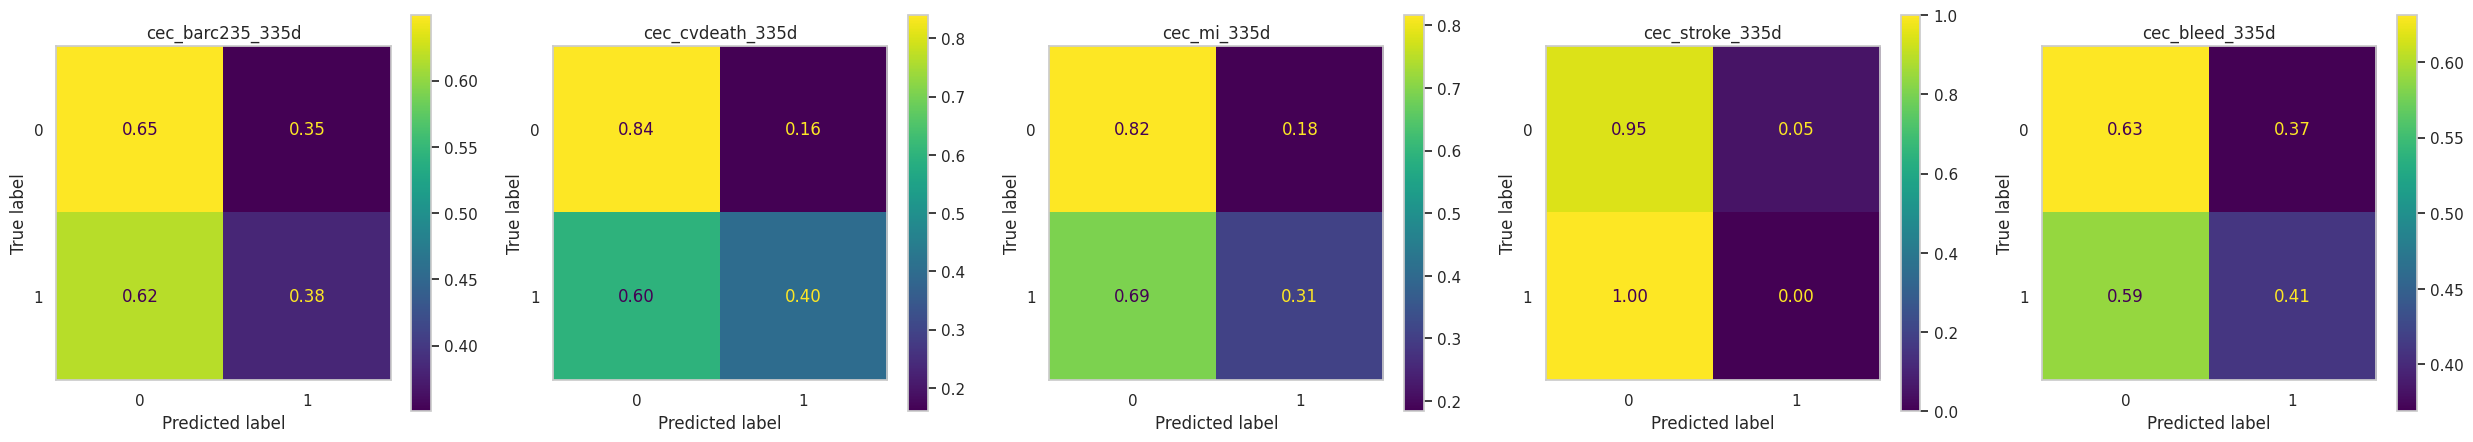

In [56]:
X_train = X_train.select_dtypes(include=[np.number])  # keep numeric features only
X_test = X_test.select_dtypes(include=[np.number])    # keep numeric features only

# Each of the 9 endpoints is treated as an independent binary target, so the
# classifier is wrapped in MultiOutputClassifier (one LogisticRegression per
# target). class_weight='balanced' compensates for the severe class
# imbalance of these endpoints (1-11% positive rate, see 01_target_exploration).
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', n_jobs=32)
    ))
])

print('Cross-validation on the training set')
evaluate_pipeline(X_train, y_train, pipe, average='macro')

# Fit on the full training set after the CV estimate above
pipe.fit(X_train, y_train)

print('Test set performance per target')
y_pred = pipe.predict(X_test)

plot_confusion_matrices(y_test, y_pred)

save_pipeline(MODULE_DIR, pipe, 'LR_gf_multioutput_sDAPT')

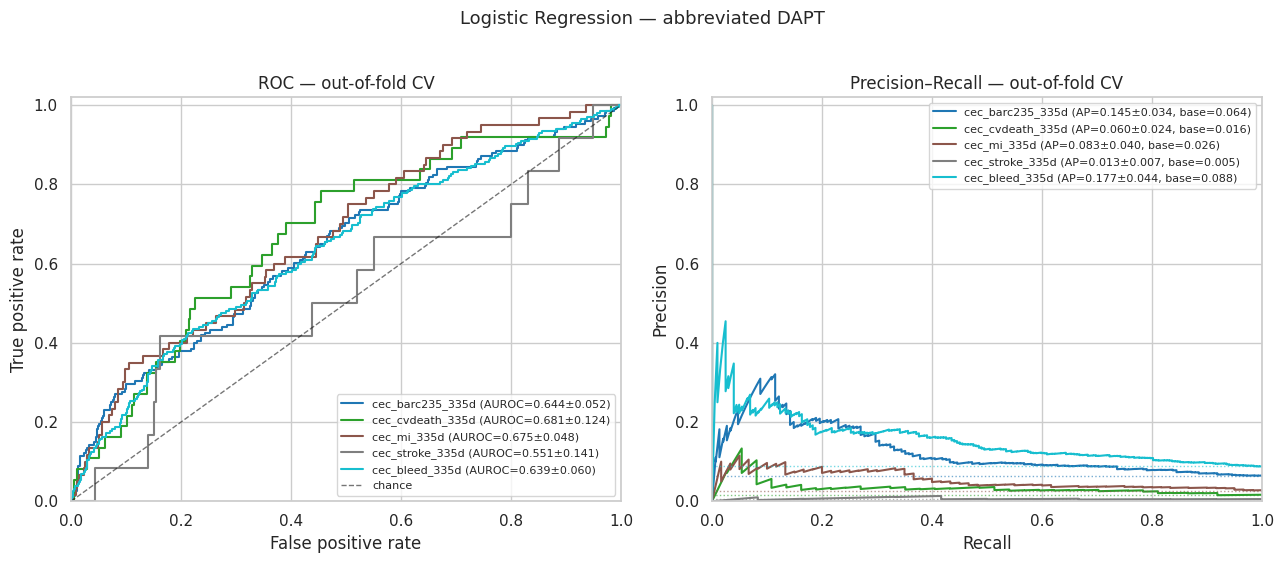

,positive_rate,AUROC,AUROC_std,AUPRC,AUPRC_std,AUPRC_lift
target,,,,,,
cec_barc235_335d,0.06,0.64,0.05,0.14,0.03,2.24
cec_cvdeath_335d,0.02,0.68,0.12,0.06,0.02,3.75
cec_mi_335d,0.03,0.67,0.05,0.08,0.04,3.17
cec_stroke_335d,0.01,0.55,0.14,0.01,0.01,2.48
cec_bleed_335d,0.09,0.64,0.06,0.18,0.04,2.01


In [57]:
# Threshold-free CV over the abbreviated-DAPT cohort: out-of-fold ROC / PR curves
# judge this model's discrimination without fixing a decision threshold (every
# row scored once while held out, preprocessing refit per fold -> no leakage).
# The leaky follow-up (fup_*) features are dropped here, as in bi-class/01; the
# baseline cell above still includes them (pending the same fix).
_leaky = [c for c in ['fup_other', 'fup_nitrates', 'fup_insulin'] if c in X.columns]
_X_cv = X.drop(columns=_leaky).select_dtypes(include=[np.number])
display(cv_roc_pr_curves(pipe, _X_cv, y_df, cv=5,
                         model_name='Logistic Regression — abbreviated DAPT'))

## Multi-output RandomForest Classification Pipeline

Split the data, build a scaling + random forest for multi-output classification, cross-validate it on the training set, fit it, and report per-target classification metrics on the held-out test set. Predictions use a per-target probability threshold tuned to the training-set event rate instead of the default 0.5, since RandomForest's averaged probabilities rarely exceed 0.5 for these rare-event targets (the CV F1 scores above are still computed at the default threshold, so they remain low for the same reason).

Cross-validation on the training set



--- cec_barc235_335d ---
average_precision scores: [0.07880571 0.1006746  0.0899667  0.07841622 0.10549832]
Mean average_precision:   0.0907 ± 0.0111   (positive rate / random AP = 0.0621)

--- cec_cvdeath_335d ---
average_precision scores: [0.01628117 0.03193481 0.01781643 0.01440656 0.11424908]
Mean average_precision:   0.0389 ± 0.0382   (positive rate / random AP = 0.0147)

--- cec_mi_335d ---
average_precision scores: [0.04196173 0.10099634 0.08174018 0.05587628 0.04735844]
Mean average_precision:   0.0656 ± 0.0224   (positive rate / random AP = 0.0256)

--- cec_stroke_335d ---
average_precision scores: [0.25892857 0.0027248  0.00787943 0.00544959 0.02355813]
Mean average_precision:   0.0597 ± 0.0999   (positive rate / random AP = 0.0049)

--- cec_bleed_335d ---
average_precision scores: [0.11454295 0.13148179 0.13748702 0.10921418 0.13495107]
Mean average_precision:   0.1255 ± 0.0114   (positive rate / random AP = 0.0888)
Test set performance per target


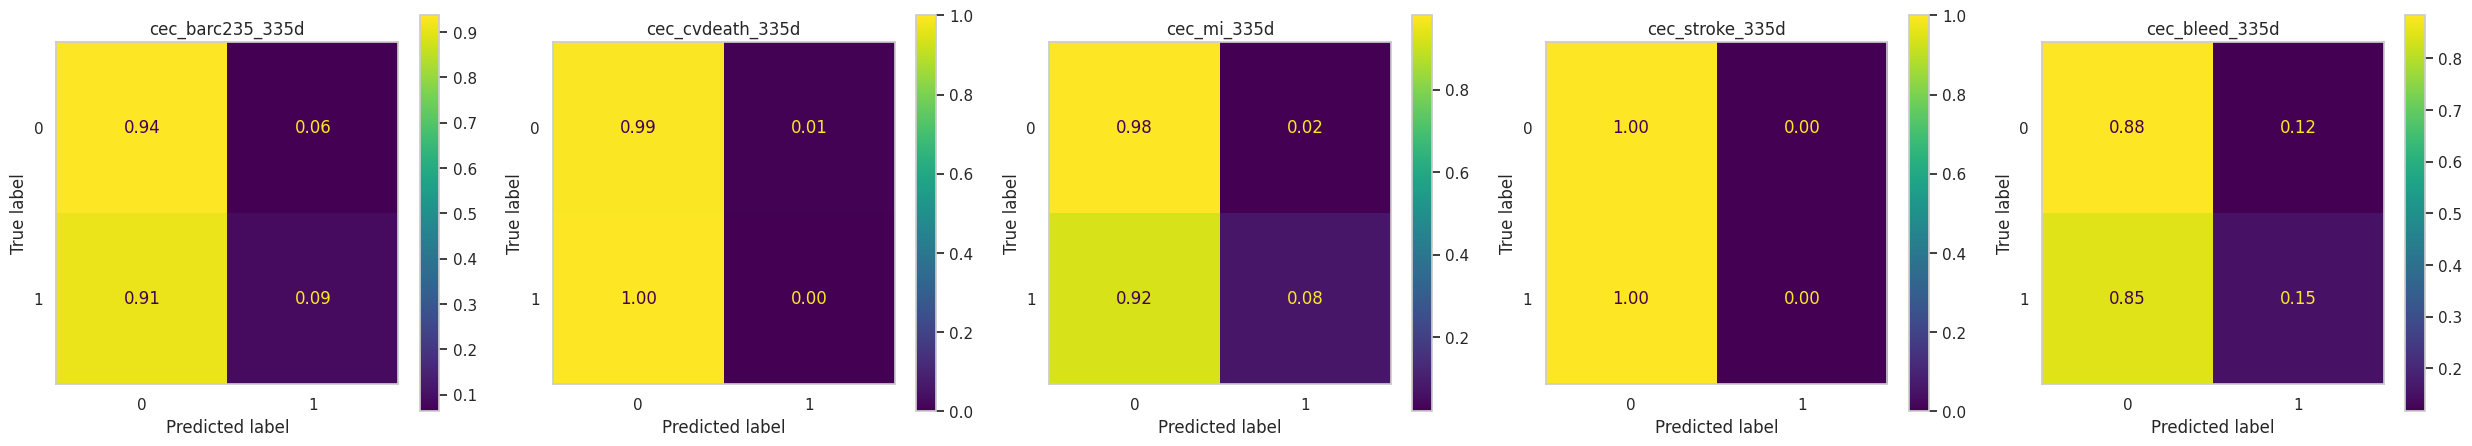

In [58]:
X_train = X_train.select_dtypes(include=[np.number])  # keep numeric features only
X_test = X_test.select_dtypes(include=[np.number])    # keep numeric features only

# One random forest per target (bleeding / ischemic) via MultiOutputClassifier.
# class_weight='balanced' reweights the impurity/leaf-value computation, but
# unlike LogisticRegression it does not shift the 0.5 decision threshold used
# by .predict(): at a ~7-11% event rate the averaged probability across all
# trees rarely exceeds 0.5, so .predict() would return 0 for every sample.
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=32)
    ))
])

print('Cross-validation on the training set')
evaluate_pipeline(X_train, y_train, pipe, average='macro')

# Fit on the full training set after the CV estimate above
pipe.fit(X_train, y_train)

print('Test set performance per target')
# Per-target threshold = (1 - event_rate) quantile of out-of-fold CV
# probabilities, so the predicted positive rate tracks the true event rate
# (see event_rate_thresholds; the raw event rate over-predicts here).
thresholds = event_rate_thresholds(pipe, X_train, y_train)
y_pred = predict_with_threshold(pipe, X_test, thresholds)

plot_confusion_matrices(y_test, y_pred)

save_pipeline(MODULE_DIR, pipe, 'RF_gf_multioutput_sDAPT')

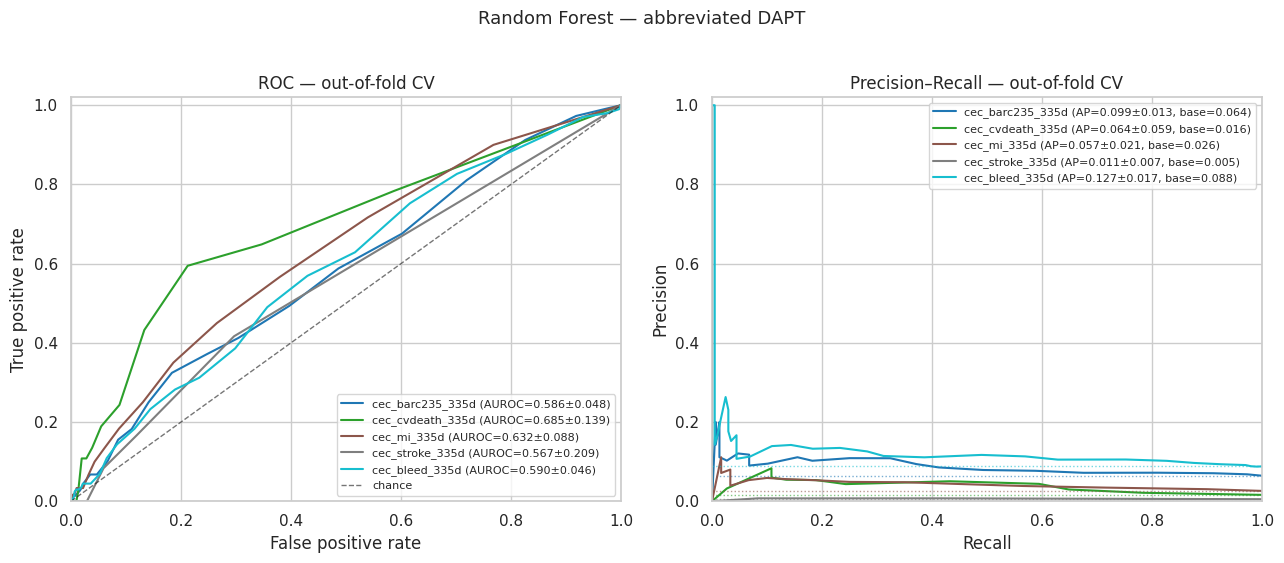

,positive_rate,AUROC,AUROC_std,AUPRC,AUPRC_std,AUPRC_lift
target,,,,,,
cec_barc235_335d,0.06,0.59,0.05,0.10,0.01,1.54
cec_cvdeath_335d,0.02,0.68,0.14,0.06,0.06,3.98
cec_mi_335d,0.03,0.63,0.09,0.06,0.02,2.19
cec_stroke_335d,0.01,0.57,0.21,0.01,0.01,2.14
cec_bleed_335d,0.09,0.59,0.05,0.13,0.02,1.44


In [59]:
# Out-of-fold ROC / PR curves for the Random Forest (see the LR cell above for
# the rationale: full-cohort CV, no threshold, fup_* leakage dropped).
_leaky = [c for c in ['fup_other', 'fup_nitrates', 'fup_insulin'] if c in X.columns]
_X_cv = X.drop(columns=_leaky).select_dtypes(include=[np.number])
display(cv_roc_pr_curves(pipe, _X_cv, y_df, cv=5,
                         model_name='Random Forest — abbreviated DAPT'))

Cross-validation on the training set



--- cec_barc235_335d ---
average_precision scores: [0.08655759 0.17149658 0.17036284 0.10136207 0.127152  ]
Mean average_precision:   0.1314 ± 0.0348   (positive rate / random AP = 0.0621)

--- cec_cvdeath_335d ---
average_precision scores: [0.01948057 0.22314804 0.01808708 0.0251384  0.03150382]
Mean average_precision:   0.0635 ± 0.0800   (positive rate / random AP = 0.0147)

--- cec_mi_335d ---
average_precision scores: [0.02859492 0.09349397 0.03280889 0.10850393 0.08964551]
Mean average_precision:   0.0706 ± 0.0332   (positive rate / random AP = 0.0256)

--- cec_stroke_335d ---
average_precision scores: [0.00959657 0.0027248  0.01081871 0.25462963 0.08496732]
Mean average_precision:   0.0725 ± 0.0959   (positive rate / random AP = 0.0049)

--- cec_bleed_335d ---
average_precision scores: [0.13303013 0.17101811 0.24965352 0.16082418 0.21768362]
Mean average_precision:   0.1864 ± 0.0418   (positive rate / random AP = 0.0888)
Test set performance per target


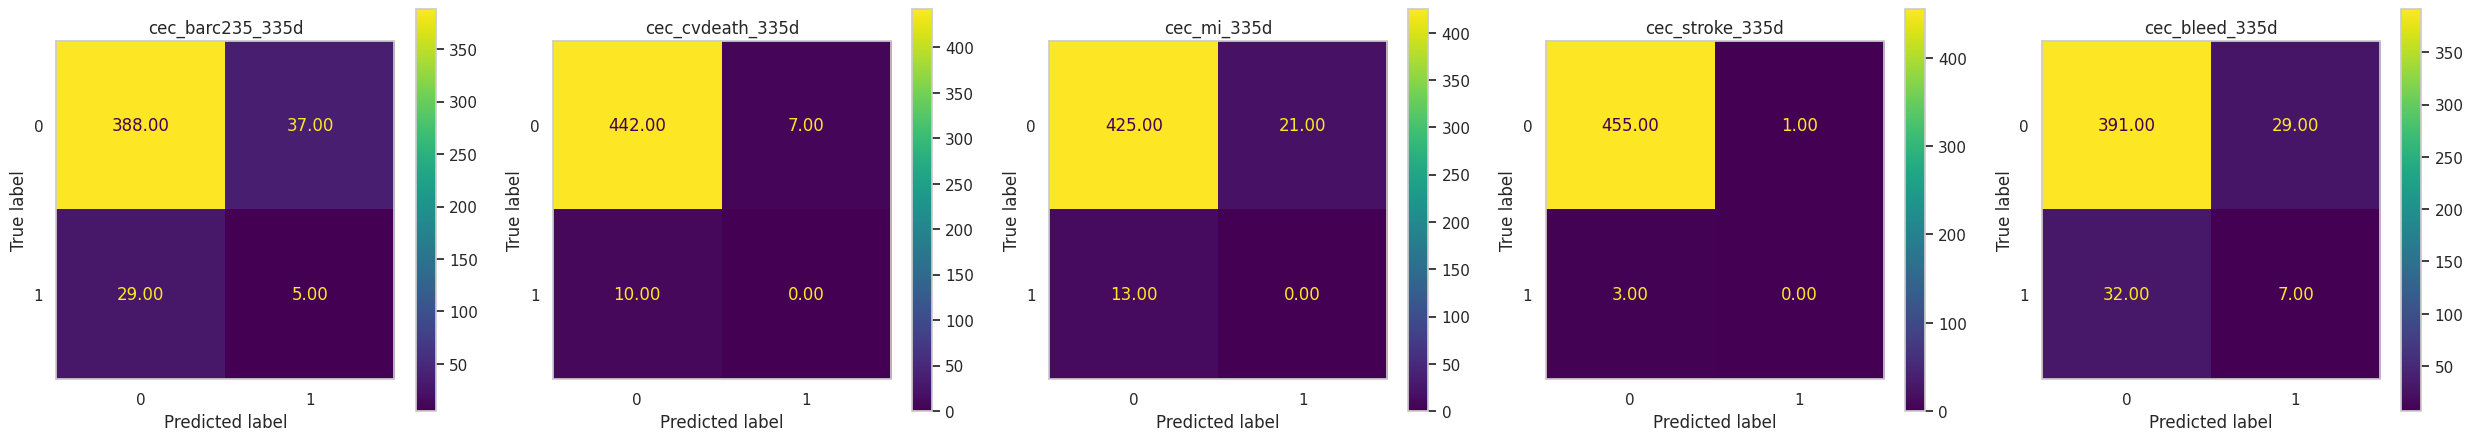

In [60]:
X_train = X_train.select_dtypes(include=[np.number])  # keep numeric features only
X_test = X_test.select_dtypes(include=[np.number])    # keep numeric features only

# One gradient boosting tree per target (bleeding / ischemic) via MultiOutputClassifier.
# class_weight='balanced' reweights the impurity/leaf-value computation, but
# unlike LogisticRegression it does not shift the 0.5 decision threshold used
# by .predict(): at a ~7-11% event rate the averaged probability across all
# trees rarely exceeds 0.5, so .predict() would return 0 for every sample.
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        GradientBoostingClassifier(random_state=42)
    ))
])

print('Cross-validation on the training set')
evaluate_pipeline(X_train, y_train, pipe, average='macro')

# Fit on the full training set after the CV estimate above
pipe.fit(X_train, y_train)

print('Test set performance per target')
# Per-target threshold = (1 - event_rate) quantile of out-of-fold CV
# probabilities, so the predicted positive rate tracks the true event rate
# (see event_rate_thresholds; the raw event rate over-predicts here).
thresholds = event_rate_thresholds(pipe, X_train, y_train)
y_pred = predict_with_threshold(pipe, X_test, thresholds)

plot_confusion_matrices(y_test, y_pred, normalize=False)

save_pipeline(MODULE_DIR, pipe, 'GB_gf_multioutput_sDAPT')

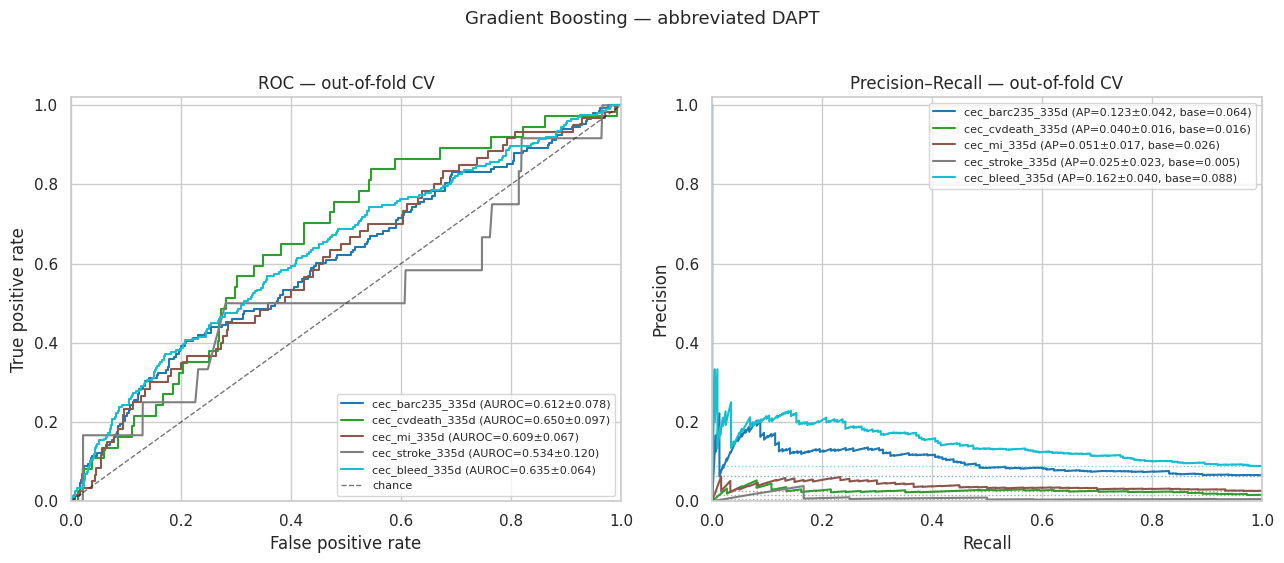

,positive_rate,AUROC,AUROC_std,AUPRC,AUPRC_std,AUPRC_lift
target,,,,,,
cec_barc235_335d,0.06,0.61,0.08,0.12,0.04,1.91
cec_cvdeath_335d,0.02,0.65,0.10,0.04,0.02,2.48
cec_mi_335d,0.03,0.61,0.07,0.05,0.02,1.97
cec_stroke_335d,0.01,0.53,0.12,0.03,0.02,4.80
cec_bleed_335d,0.09,0.64,0.06,0.16,0.04,1.84


In [61]:
# Out-of-fold ROC / PR curves for the Gradient Boosting model (see the LR cell
# above for the rationale: full-cohort CV, no threshold, fup_* leakage dropped).
_leaky = [c for c in ['fup_other', 'fup_nitrates', 'fup_insulin'] if c in X.columns]
_X_cv = X.drop(columns=_leaky).select_dtypes(include=[np.number])
display(cv_roc_pr_curves(pipe, _X_cv, y_df, cv=5,
                         model_name='Gradient Boosting — abbreviated DAPT'))

## Bayesian Hyperparameter Tuning

Random and grid search waste budget exploring the whole parameter space uniformly. Optuna's Tree-structured Parzen Estimator (TPE) builds a probabilistic model of the objective surface after each trial and concentrates subsequent trials where the objective is likely to be high.

**Objective**: mean macro precision across all targets on the training set (3-fold CV).
**Trials**: 50 / 30 / 20 for Logistic Regression / Random Forest / Gradient Boosting.
After the search, the best hyperparameters are used to fit the final model and evaluate it on the held-out test set — using the same evaluation protocol as the baseline models above (standard `.predict()` for LR, threshold-tuned probabilities for RF and GB).

In [62]:
import optuna
from sklearn.metrics import make_scorer, precision_score

optuna.logging.set_verbosity(optuna.logging.WARNING)


def _multioutput_macro_precision(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    return float(np.mean([
        precision_score(y_true[:, i], y_pred[:, i], average='macro', zero_division=0)
        for i in range(y_true.shape[1])
    ]))

_mo_scorer = make_scorer(_multioutput_macro_precision)


def mean_cv_precision(pipeline, X, y, cv=3):
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring=_mo_scorer, error_score=np.nan)
    return float(np.nanmean(scores))

### Logistic Regression

Search space: regularisation strength `C` (log-uniform in [0.001, 100]) and `solver` (lbfgs / liblinear / saga, all with L2 penalty).

In [63]:
def _lr_objective(trial):
    C = trial.suggest_float('C', 1e-3, 1e2, log=True)
    solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga'])
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler()),
        ('classifier', MultiOutputClassifier(
            LogisticRegression(C=C, solver=solver, max_iter=2000,
                               random_state=42, class_weight='balanced'),
            n_jobs=-1,
        )),
    ])
    return mean_cv_precision(pipe, X_train, y_train)


study_lr = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_lr.optimize(_lr_objective, n_trials=50, show_progress_bar=True)

# Baseline (default C=1, lbfgs) for delta comparison
_baseline_lr_precision = mean_cv_precision(Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        n_jobs=-1,
    )),
]), X_train, y_train)

print('Best params:', study_lr.best_params)
print(f'Tuned  CV macro-precision: {study_lr.best_value:.4f}')
print(f'Base   CV macro-precision: {_baseline_lr_precision:.4f}  '
      f'(Δ = {study_lr.best_value - _baseline_lr_precision:+.4f})')

Best trial: 11. Best value: 0.523852: 100%|██████████| 50/50 [01:14<00:00,  1.49s/it]


Best params: {'C': 70.41830285015996, 'solver': 'liblinear'}
Tuned  CV macro-precision: 0.5239
Base   CV macro-precision: 0.5234  (Δ = +0.0005)


Test set performance — Tuned Logistic Regression

--- cec_barc235_335d ---
              precision    recall  f1-score   support

         0.0       0.93      0.64      0.76       425
         1.0       0.07      0.35      0.12        34

    accuracy                           0.62       459
   macro avg       0.50      0.50      0.44       459
weighted avg       0.86      0.62      0.71       459


--- cec_cvdeath_335d ---
              precision    recall  f1-score   support

         0.0       0.98      0.86      0.92       449
         1.0       0.06      0.40      0.10        10

    accuracy                           0.85       459
   macro avg       0.52      0.63      0.51       459
weighted avg       0.96      0.85      0.90       459


--- cec_mi_335d ---
              precision    recall  f1-score   support

         0.0       0.98      0.83      0.90       446
         1.0       0.06      0.38      0.10        13

    accuracy                           0.81       459
   mac

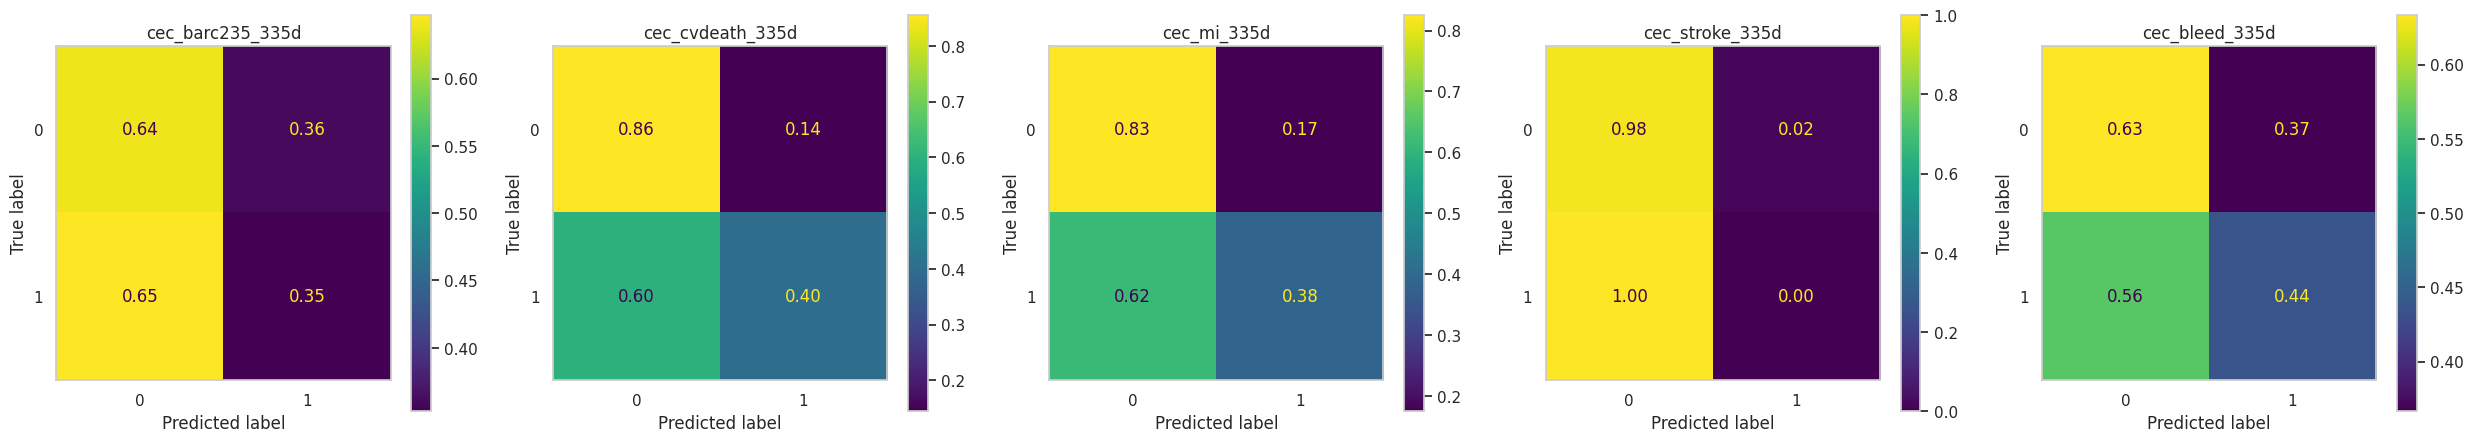

In [64]:
_p = study_lr.best_params
best_lr_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        LogisticRegression(C=_p['C'], solver=_p['solver'],
                           max_iter=2000, random_state=42, class_weight='balanced'),
        n_jobs=-1,
    )),
])
best_lr_pipe.fit(X_train, y_train)

print('Test set performance — Tuned Logistic Regression')
_y_pred = best_lr_pipe.predict(X_test)
for i, col in enumerate(y_test.columns):
    print(f"\n--- {col} ---")
    print(classification_report(y_test.iloc[:, i], _y_pred[:, i], zero_division=0))

plot_confusion_matrices(y_test, _y_pred)

### Random Forest

Search space: `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`. For the test evaluation the per-target decision threshold is derived from the (1 − event_rate) quantile of the model's predicted training-set probabilities, making it adaptive to the actual probability range produced by the tuned hyperparameters.

In [ ]:
def _rf_objective(trial):
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler()),
        ('classifier', MultiOutputClassifier(
            RandomForestClassifier(
                n_estimators=trial.suggest_int('n_estimators', 50, 200, step=50),
                max_depth=trial.suggest_categorical('max_depth', [None, 5, 10, 15, 20]),
                min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
                max_features=trial.suggest_categorical('max_features', ['sqrt', 'log2']),
                class_weight='balanced', random_state=42, n_jobs=2,
            ),
            n_jobs=-1,
        )),
    ])
    return mean_cv_precision(pipe, X_train, y_train)


study_rf = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(_rf_objective, n_trials=30, show_progress_bar=True)

_baseline_rf_precision = mean_cv_precision(Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=2),
        n_jobs=-1,
    )),
]), X_train, y_train)

print('Best params:', study_rf.best_params)
print(f'Tuned  CV macro-precision: {study_rf.best_value:.4f}')
print(f'Base   CV macro-precision: {_baseline_rf_precision:.4f}  '
      f'(Δ = {study_rf.best_value - _baseline_rf_precision:+.4f})')

Best trial: 1. Best value: 0.543115:  50%|█████     | 15/30 [00:25<00:20,  1.36s/it]

Test set performance — Tuned Random Forest

--- cec_barc235_335d ---
              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93       425
         1.0       0.09      0.09      0.09        34

    accuracy                           0.87       459
   macro avg       0.51      0.51      0.51       459
weighted avg       0.87      0.87      0.87       459


--- cec_cvdeath_335d ---
              precision    recall  f1-score   support

         0.0       0.98      0.96      0.97       449
         1.0       0.11      0.20      0.14        10

    accuracy                           0.95       459
   macro avg       0.55      0.58      0.56       459
weighted avg       0.96      0.95      0.95       459


--- cec_mi_335d ---
              precision    recall  f1-score   support

         0.0       0.97      0.93      0.95       446
         1.0       0.03      0.08      0.04        13

    accuracy                           0.91       459
   macro avg

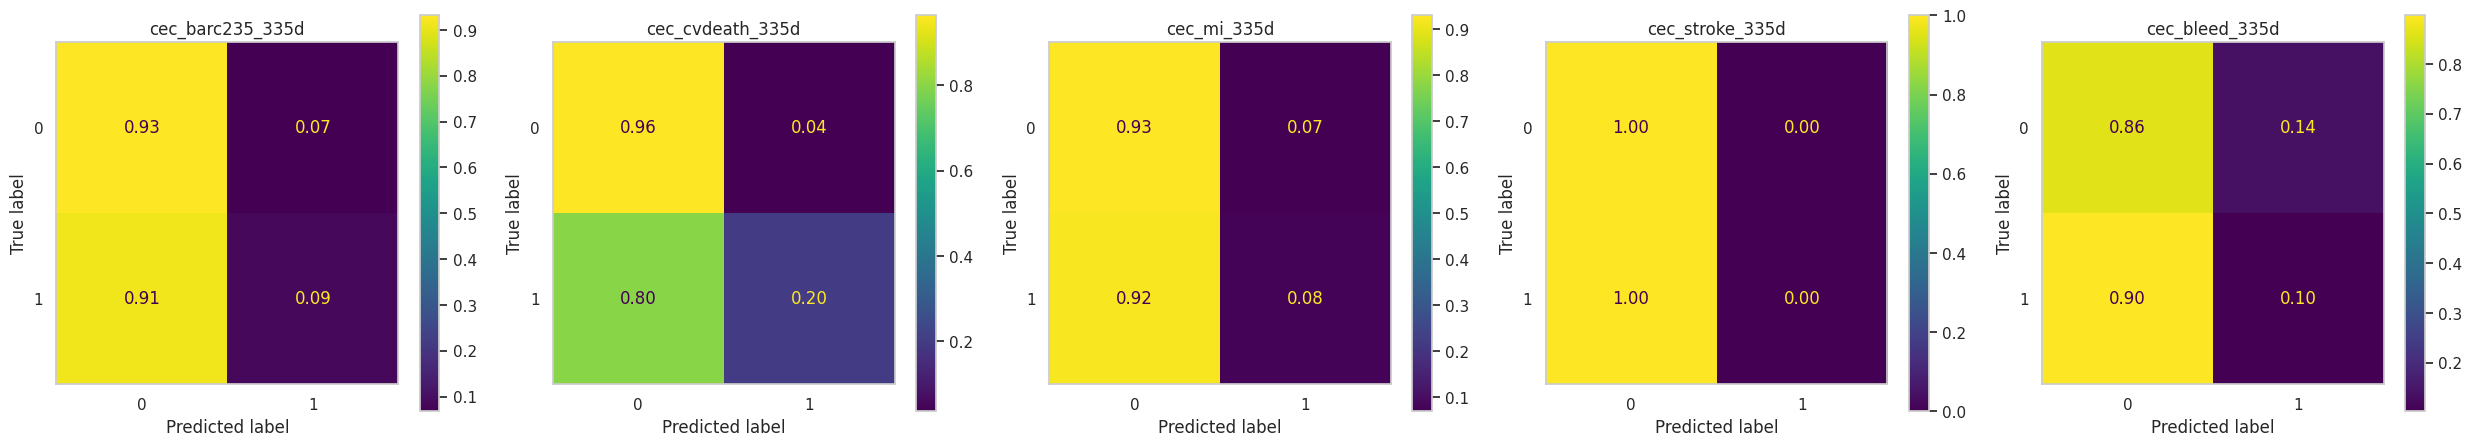

In [ ]:
_p = study_rf.best_params
best_rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        RandomForestClassifier(
            n_estimators=_p['n_estimators'], max_depth=_p['max_depth'],
            min_samples_split=_p['min_samples_split'],
            min_samples_leaf=_p['min_samples_leaf'],
            max_features=_p['max_features'],
            class_weight='balanced', random_state=42, n_jobs=-1,
        ),
        n_jobs=-1,
    )),
])
best_rf_pipe.fit(X_train, y_train)

# Per-target thresholds from the (1 - event_rate) quantile of out-of-fold
# probabilities.  Using out-of-fold rather than in-sample probabilities is
# essential here: the tuned trees overfit the training set, so an in-sample
# quantile threshold lands far above the test probabilities and predicts the
# negative class for every row.
_thresholds = event_rate_thresholds(best_rf_pipe, X_train, y_train)

print('Test set performance — Tuned Random Forest')
_y_pred = predict_with_threshold(best_rf_pipe, X_test, _thresholds)
for i, col in enumerate(y_test.columns):
    print(f"\n--- {col} ---")
    print(classification_report(y_test.iloc[:, i], _y_pred[:, i], zero_division=0))

plot_confusion_matrices(y_test, _y_pred)

### Gradient Boosting

Search space: `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `min_samples_split`, `max_features`. Same quantile-based evaluation as RF.

In [ ]:
def _gb_objective(trial):
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler()),
        ('classifier', MultiOutputClassifier(
            GradientBoostingClassifier(
                n_estimators=trial.suggest_int('n_estimators', 50, 200, step=50),
                max_depth=trial.suggest_int('max_depth', 2, 6),
                learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample=trial.suggest_float('subsample', 0.6, 1.0),
                min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
                max_features=trial.suggest_categorical('max_features', ['sqrt', 'log2']),
                random_state=42,
            ),
            n_jobs=-1,
        )),
    ])
    return mean_cv_precision(pipe, X_train, y_train)


study_gb = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_gb.optimize(_gb_objective, n_trials=20, show_progress_bar=True)

_baseline_gb_precision = mean_cv_precision(Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        GradientBoostingClassifier(random_state=42),
        n_jobs=-1,
    )),
]), X_train, y_train)

print('Best params:', study_gb.best_params)
print(f'Tuned  CV macro-precision: {study_gb.best_value:.4f}')
print(f'Base   CV macro-precision: {_baseline_gb_precision:.4f}  '
      f'(Δ = {study_gb.best_value - _baseline_gb_precision:+.4f})')

Best trial: 16. Best value: 0.534688: 100%|██████████| 20/20 [00:16<00:00,  1.18it/s]


Best params: {'n_estimators': 150, 'max_depth': 2, 'learning_rate': 0.28849822405045517, 'subsample': 0.6035508107692334, 'min_samples_split': 3, 'max_features': 'log2'}
Tuned  CV macro-precision: 0.5347
Base   CV macro-precision: 0.5390  (Δ = -0.0043)


Test set performance — Tuned Gradient Boosting

--- cec_barc235_335d ---
              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93       425
         1.0       0.12      0.12      0.12        34

    accuracy                           0.87       459
   macro avg       0.53      0.52      0.53       459
weighted avg       0.87      0.87      0.87       459


--- cec_cvdeath_335d ---
              precision    recall  f1-score   support

         0.0       0.98      0.96      0.97       449
         1.0       0.09      0.20      0.12        10

    accuracy                           0.94       459
   macro avg       0.54      0.58      0.55       459
weighted avg       0.96      0.94      0.95       459


--- cec_mi_335d ---
              precision    recall  f1-score   support

         0.0       0.98      0.97      0.97       446
         1.0       0.14      0.15      0.15        13

    accuracy                           0.95       459
   macro

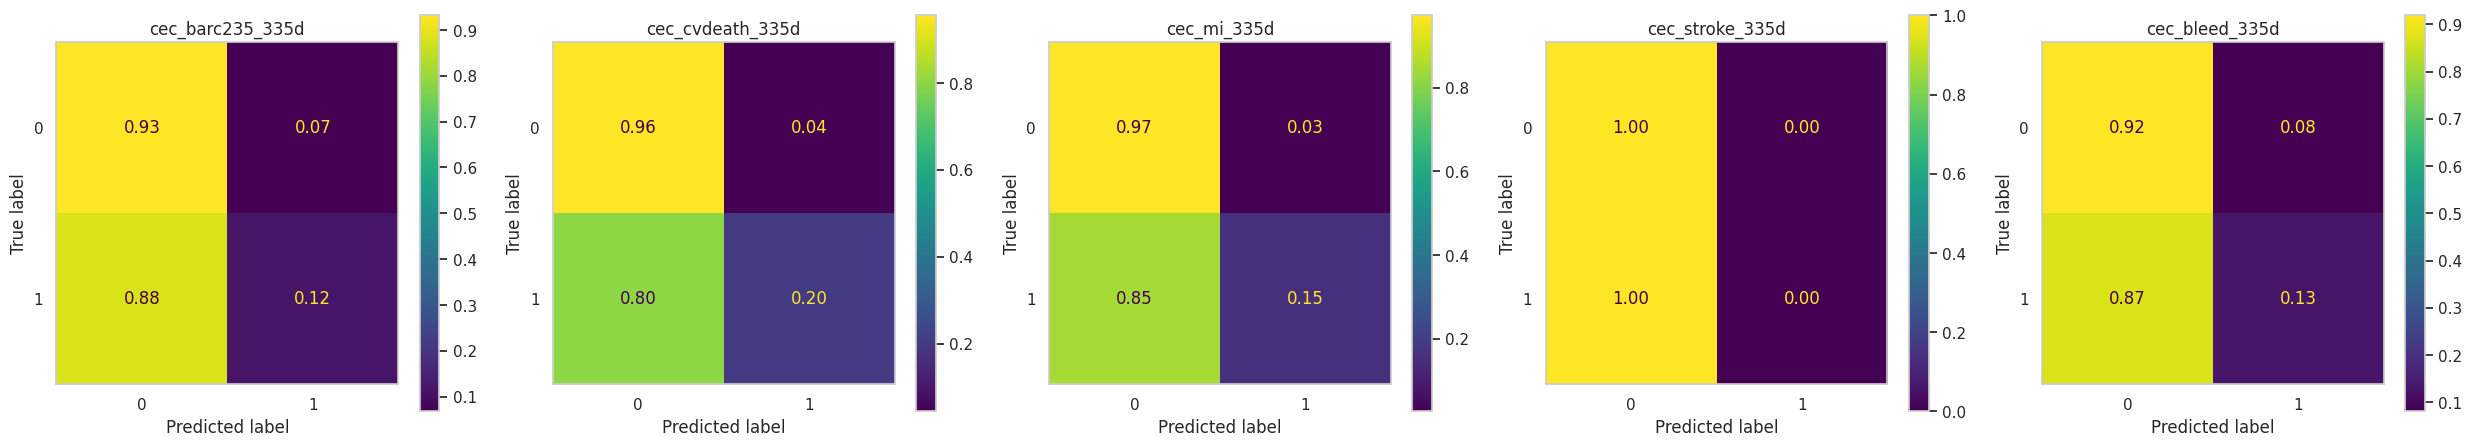

In [ ]:
_p = study_gb.best_params
best_gb_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        GradientBoostingClassifier(
            n_estimators=_p['n_estimators'], max_depth=_p['max_depth'],
            learning_rate=_p['learning_rate'], subsample=_p['subsample'],
            min_samples_split=_p['min_samples_split'], max_features=_p['max_features'],
            random_state=42,
        ),
        n_jobs=-1,
    )),
])
best_gb_pipe.fit(X_train, y_train)

# Same out-of-fold quantile thresholds as for the tuned RF above, for consistency.
_thresholds = event_rate_thresholds(best_gb_pipe, X_train, y_train)

print('Test set performance — Tuned Gradient Boosting')
_y_pred = predict_with_threshold(best_gb_pipe, X_test, _thresholds)
for i, col in enumerate(y_test.columns):
    print(f"\n--- {col} ---")
    print(classification_report(y_test.iloc[:, i], _y_pred[:, i], zero_division=0))

plot_confusion_matrices(y_test, _y_pred)

### Summary

Comparison of cross-validated mean macro precision (3-fold, training set) before and after Bayesian tuning, and the convergence of the best-so-far objective across trials.

              Model  Baseline CV Precision  Tuned CV Precision  Δ Precision
Logistic Regression                   0.52                0.52         0.00
      Random Forest                   0.48                0.56         0.08
  Gradient Boosting                   0.54                0.53        -0.00


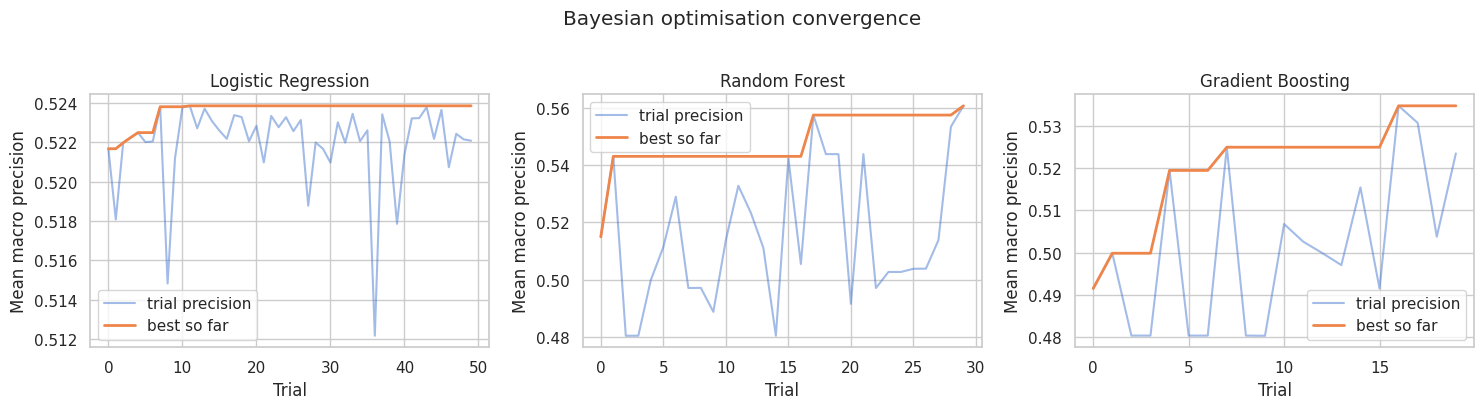

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Baseline CV Precision': [_baseline_lr_precision, _baseline_rf_precision, _baseline_gb_precision],
    'Tuned CV Precision':    [study_lr.best_value, study_rf.best_value, study_gb.best_value],
})
comparison['Δ Precision'] = comparison['Tuned CV Precision'] - comparison['Baseline CV Precision']
print(comparison.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, (name, study) in zip(
    axes,
    [('Logistic Regression', study_lr),
     ('Random Forest',       study_rf),
     ('Gradient Boosting',   study_gb)],
):
    vals = [t.value for t in study.trials if t.value is not None]
    best_so_far = np.maximum.accumulate(vals)
    ax.plot(vals, alpha=0.5, label='trial precision')
    ax.plot(best_so_far, linewidth=2, label='best so far')
    ax.set_title(name)
    ax.set_xlabel('Trial')
    ax.set_ylabel('Mean macro precision')
    ax.legend()
plt.suptitle('Bayesian optimisation convergence', y=1.02)
plt.tight_layout()
plt.show()